# Caso Práctico: Regresión Lineal

**¿Qué es regresión?**


Es un proceso que permite la estimación de las relaciones funcionales entre variables. En el campo de aprendizaje automático es ampliamente utilizado para la predicción del valor de una variable dependiente, a partir de una o más variables explicativas. El modelo de regresión puede ser lineal o no lineal.


**¿Qué preguntas se pueden respodner mediante regresiones?**

- ¿Cómo varían el volumen de ventas cuando subimos los precios?
- ¿Afecta el nombre de un producto a su contratación?
- ¿Cuántos clientes contratarán hoy un plan de pensiones?


**¿Cuándo usar regresión lineal?**

- Cuando queremos predecir el valor de una variable a partir de otras.
- Si queremos explicar o entender la relación entre dos o más atributos.

---

## Regresión lineal simple

Los problemas de regresión tienen una estructura común: una variable respuesta ($y$) que puede ser expresada como combinación de una o más variables independientes ($x_i$), llamadas covariables o predictores. El algoritmo de regresión intenta construir un modelo que exprese la variable respuesta en función de las covariables, como:

$$y = a_1x_1 + a_2x_2 + \ldots + a_nx_n$$

donde $a_i$ son los parámetros del modelo, llamados coeficientes. El modelo se ajusta mediante Mínimos Cuadrados Ordinarios (OLS en inglés), donde los coeficientes son elegidos para minimizar el cuadrado de la distancia (vertical) entre los valores predichos y los reales.

*Ejemplo*. Para entender las funcionalidades de Python para regresión vamos a construir un modelo sencillo de regresión a partir de datos sintéticos usando varias librerías científicas de Python.  

Para ello vamos a generar 300 valores aleatorios de una distribución Gaussiana, los multiplicamos por unos coeficientes que les den una forma aproximadamente lineal.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#  Números decimales muestreados de una distribución Normal estándar
datos = np.random.randn(300, 2)
pesos = np.array([[0.6, .4], [.4, 0.6]])
datos = np.dot(datos, pesos)

x = datos[:,0]
y = datos[:,1]

/tmp/ipython-input-981183929.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x, y, "ro", c='orange', alpha=0.3)


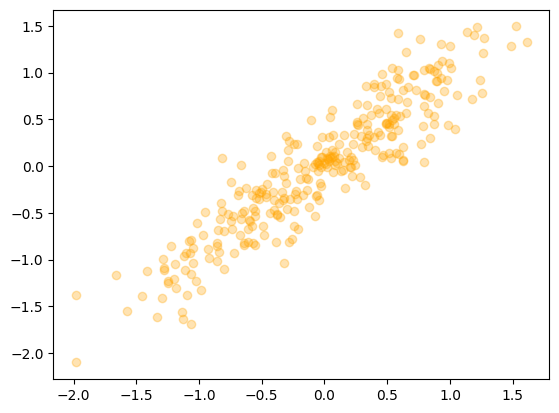

In [3]:
plt.plot(x, y, "ro", c='orange', alpha=0.3)

In [4]:
type(x)

numpy.ndarray

### Scikit-learn

Scikit-learn posee una interfaz orientada a objetos basada en el concepto de un *Estimador*

El método <code>Estimator.fit</code> establece el estado del estimador de acuerdo a los datos de entrenamiento. Usualmente estos datos están representdos por un `numpy.array` bidimensional $x$ con dimensiones <code>(n_muestras, n_predictores)</code> que contiene la matriz de características, y un `numpy.array` unidimensional que contiene los valores de la variable de respuesta $y$.

In [5]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [6]:
x.shape

(300,)

In [7]:
x = x.reshape(-1,1)

In [8]:
x.shape

(300, 1)

In [9]:
x

array([[ 0.25909698],
       [-0.62889841],
       [-0.19283985],
       [-0.16238947],
       [-1.19380616],
       [ 0.20178283],
       [-0.06171628],
       [ 0.65485573],
       [ 0.52701296],
       [ 0.33797279],
       [ 0.20869294],
       [ 0.45933322],
       [ 0.79641126],
       [ 0.05848034],
       [ 0.65222981],
       [-0.3795361 ],
       [ 1.19002076],
       [-1.97915817],
       [-0.96936242],
       [ 0.34329955],
       [ 0.19220799],
       [-0.39460039],
       [-0.72146432],
       [-0.28560625],
       [-1.22252481],
       [-0.00493016],
       [-1.07019088],
       [ 0.89688101],
       [ 0.15932987],
       [ 0.62796224],
       [ 0.95225428],
       [-0.83907048],
       [ 0.03385314],
       [-0.28972311],
       [ 0.24211326],
       [-0.65536641],
       [ 0.36888844],
       [ 0.42320002],
       [ 0.30735715],
       [ 0.05871314],
       [ 0.48847363],
       [ 1.61263576],
       [-0.35266604],
       [ 0.1453671 ],
       [ 1.25179294],
       [ 0

Coeficientes:  0.02447023839194415 [0.93332989]
Error medio:  0.21694962784162897


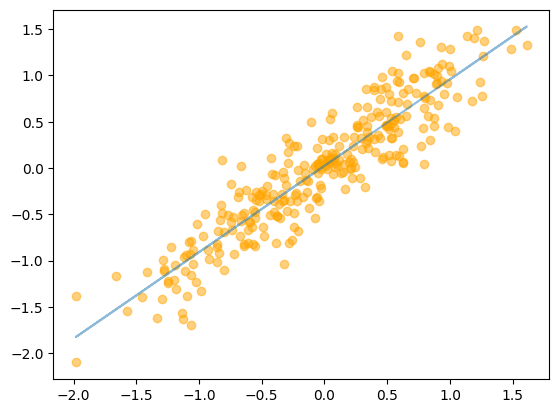

In [11]:
regr = LinearRegression(fit_intercept=True)
regr.fit(x, y)
y_hat = regr.predict(x)

print('Coeficientes: ', regr.intercept_, regr.coef_)
print('Error medio: ', mean_absolute_error(y, y_hat))

plt.scatter(x, y, c='orange', marker='o', alpha=0.5)
plt.plot(x, y_hat, alpha=0.5)

El método ``Estimator.predict`` permite hacer predicciones. En el caso de regresión, este método devuelve los valores predichos por el modelo.

Existe también un objeto `Estimator` especial llamado `Transformer` que permite realizar transformaciones sobre los datos. En el caso de regresión, una transformación adecuada es la de normalizar los predictores, tal que tengan media cero y desviación típica 1 con ``sklearn.preprocessing.StandardScaler``

---

# Regresión lineal múltiple

## Caso: Predicción de Picos de Intensidad de impactos en un Molino SAG

### 1. Importación de Librerías

In [12]:
import matplotlib #.pyplot as plt1
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [13]:
warnings.filterwarnings("ignore")
%matplotlib inline

### 2. Importación de Datos

In [14]:
df = pd.read_csv('01 dbCasoPracticoMolino.csv',delimiter=';')
df.head()

,Fecha,SAG Run Sts,Presion,Intensidad de impactos,Tonelaje,Velocidad,%Solidos,Potencia,F80,Brazo
0,21-ago-20 07:00:00,Shutdown,Shutdown,[-11059] No Good Data For Calculation,[-11059] No Good Data For Calculation,Shutdown,Shutdown,Shutdown,Shutdown,Shutdown
1,21-ago-20 07:01:00,Shutdown,341.994812,[-11059] No Good Data For Calculation,[-11059] No Good Data For Calculation,Shutdown,Shutdown,Shutdown,Shutdown,Shutdown
2,21-ago-20 07:02:00,Shutdown,339.9818726,[-11059] No Good Data For Calculation,[-11059] No Good Data For Calculation,Shutdown,Shutdown,Shutdown,Shutdown,Shutdown
3,21-ago-20 07:03:00,Shutdown,336.7662659,[-11059] No Good Data For Calculation,[-11059] No Good Data For Calculation,Shutdown,Shutdown,Shutdown,Shutdown,Shutdown
4,21-ago-20 07:04:00,Shutdown,334.7826538,[-11059] No Good Data For Calculation,[-11059] No Good Data For Calculation,Shutdown,Shutdown,Shutdown,Shutdown,Shutdown


In [15]:
df.shape

(15420, 10)

In [16]:
df.groupby('Intensidad de impactos').count()

,Fecha,SAG Run Sts,Presion,Tonelaje,Velocidad,%Solidos,Potencia,F80,Brazo
Intensidad de impactos,,,,,,,,,
100.0393335,1,1,1,1,1,1,1,1,1
100.057541,1,1,1,1,1,1,1,1,1
101.1941306,1,1,1,1,1,1,1,1,1
101.8629246,1,1,1,1,1,1,1,1,1
102.5471041,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...
93.90643677,1,1,1,1,1,1,1,1,1
94.55850583,1,1,1,1,1,1,1,1,1
99.18323506,1,1,1,1,1,1,1,1,1


### 3. Limpieza de Datos

In [17]:
titles=list(df)

In [18]:
titles

['Fecha',
 'SAG Run Sts',
 'Presion',
 'Intensidad de impactos',
 'Tonelaje',
 'Velocidad',
 '%Solidos',
 'Potencia',
 'F80',
 'Brazo']

In [19]:
##Tratamiento de datos invalidos
#-------------------------------------------

for col in titles:
    #Eliminar filas cuyo valor en columna tenga un dato vacio
    df=df.dropna(subset=[col])
    #Eliminar valores invalidos
    df = df.drop(df[(df[col]=='Bad') | (df[col]=='Shutdown') | (df[col]=='I/O Timeout')| (df[col]=='[-11059] No Good Data For Calculation') | (df[col]==' ')].index)

#Filtro Sag encendido
df = df.drop(df[df['SAG Run Sts']=='Stop'].index)
df = df.drop(['SAG Run Sts'], axis=1)
df.isnull().sum(axis=0)

df = df.drop(['Fecha'], axis=1) # Igual a: df.drop(['Fecha'], axis='columns', inplace=True)
df=df.astype(float).round(2)

In [20]:
df.head()

,Presion,Intensidad de impactos,Tonelaje,Velocidad,%Solidos,Potencia,F80,Brazo
316,6144.83,52.49,3323.11,8.83,74.20,10869.21,67.60,2.01
317,6143.40,52.83,3293.34,8.83,74.47,10867.19,67.42,1.99
318,6139.66,54.74,3331.12,8.83,74.50,10795.39,67.46,2.00
319,6138.42,57.07,3289.88,8.84,74.50,10801.26,67.08,2.01
320,6135.47,54.66,3286.99,8.84,74.26,10883.07,66.57,2.01


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14375 entries, 316 to 15419
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Presion                 14375 non-null  float64
 1   Intensidad de impactos  14375 non-null  float64
 2   Tonelaje                14375 non-null  float64
 3   Velocidad               14375 non-null  float64
 4   %Solidos                14375 non-null  float64
 5   Potencia                14375 non-null  float64
 6   F80                     14375 non-null  float64
 7   Brazo                   14375 non-null  float64
dtypes: float64(8)
memory usage: 1010.7 KB


<Axes: >

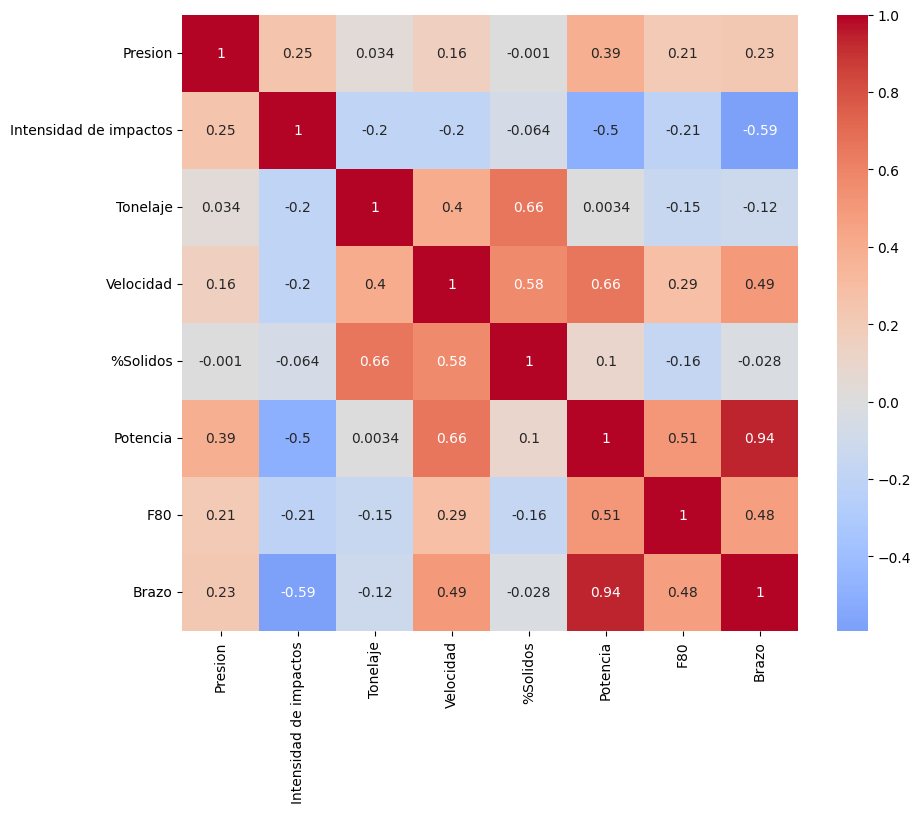

In [22]:
#1. Analisis de Correlaciones de Pearson
corr_mat=df.corr(method='pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr_mat,vmax=1,square=True,annot=True,center= 0,cmap='coolwarm') # other params: linewidths=3, linecolor='black'

### 4. Modelamiento Predictivo

In [46]:
#col = lista
col = df.columns
col

Index(['Presion', 'Intensidad de impactos', 'Tonelaje', 'Velocidad',
       '%Solidos', 'Potencia', 'F80', 'Brazo'],
      dtype='object')

In [49]:
# Target: Variable que intentamos pronosticar
target_col = "Intensidad de impactos"

# Definicion de variables de estudio
X = df.loc[:, col != target_col]

y = df.loc[:, target_col]

#Realizamos una selección de muestra ENTRENAMIENTO Y VALIDACION aletoria y comparables muestras, con
#fines de validar el aprendizaje de nuestro modelo
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.30,
                                                    random_state=42)

In [50]:
def indicadores_regresion(y_test,y_pred):
    # Calculamos el Root Mean Square Error: Suma(Y_reales-Y_predichos)^2/n
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Definimos y calculamos el MAPE (mean_absolute_percentage_error)
    y_test, y_pred = np.array(y_test), np.array(y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    return rmse,mape

#### 4.1. Modelo de Regresion Lineal

In [26]:
from sklearn.linear_model import LinearRegression

In [51]:
# Entrenamiento del modelo
model_regression_lineal = LinearRegression()
model_regression_lineal.fit(X_train, y_train)

LinearRegression()

In [52]:
# Predecir el conjunto de test
y_pred = model_regression_lineal.predict(X_test)

In [53]:
residual = y_test - y_pred
residual

,Intensidad de impactos
9759,1.421085e-14
6365,2.273737e-13
10099,-2.380318e-13
13437,0.000000e+00
11873,-3.801404e-13
...,...
11702,6.750156e-14
9091,2.415845e-13
15035,-4.796163e-13
15169,4.867218e-13


RMSE: 2.2141052246212588e-13 - MAPE: 6.589591742712987e-13


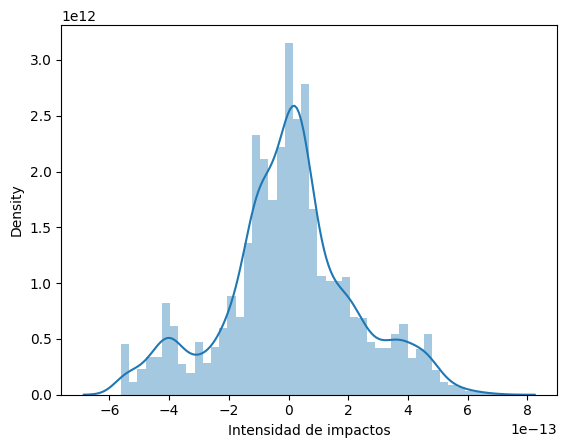

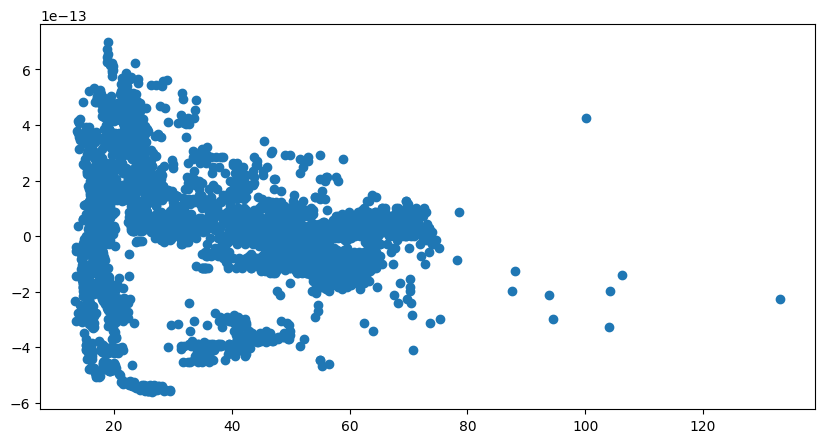

In [54]:

# Mostrar indicadores de precision
rmse, mape = indicadores_regresion(y_test,y_pred)
print(f'RMSE: {rmse} - MAPE: {mape}')

# Gráfico: Validación del Residual como una Distribución Normal
ax = sns.distplot(residual)

# Gráfico: Validación de Homocedasticidad
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(y_pred, residual)

In [55]:
# regression coefficients and R-squared value of model
print(model_regression_lineal.intercept_, model_regression_lineal.coef_, model_regression_lineal.score(X_train, y_train))

5.201172825763933e-12 [-8.40756546e-16  1.00000000e+00  9.36750677e-17  1.11622164e-13
 -1.92132229e-15 -1.11022302e-16  4.77048956e-17] 1.0


In [56]:
ecuacion_regresion = dict(zip(X_train.columns, model_regression_lineal.coef_))
ecuacion_regresion['INTERCEPTO'] = model_regression_lineal.intercept_
ecuacion_regresion

{'Presion': np.float64(-8.407565455368461e-16),
 'Intensidad de impactos': np.float64(0.9999999999999999),
 'Tonelaje': np.float64(9.367506770274758e-17),
 'Velocidad': np.float64(1.1162216441949757e-13),
 '%Solidos': np.float64(-1.9213222931580877e-15),
 'Potencia': np.float64(-1.1102230246251565e-16),
 'F80': np.float64(4.7704895589362195e-17),
 'INTERCEPTO': np.float64(5.201172825763933e-12)}